In [16]:
!pip install datasets pandas matplotlib transformers -q

In [17]:
import re
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import pipeline

In [19]:
dataset = load_dataset("openai/gsm8k", "main")

samples = dataset["test"].select(range(10))

In [20]:
generator = pipeline(
    "text-generation",
    model="google/flan-t5-small"
)

Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLl

In [21]:
def zero_shot_prompt(question):
    return f"""
Solve the following math problem.
Give only the final answer.

Question: {question}
"""

In [22]:
def few_shot_prompt(question):
    return f"""
Solve the following math problems.

Example 1:
Question: Ravi has 3 apples and buys 2 more. How many apples?
Answer: 5

Example 2:
Question: There are 4 pencils in 3 boxes. Total pencils?
Answer: 12

Now solve:

Question: {question}
Answer:
"""

In [23]:
def cot_prompt(question):
    return f"""
Solve the following math problem step by step.
Then give the final answer.

Question: {question}
"""

In [24]:
def get_response(prompt):
    output = generator(
        prompt,
        max_length=128,
        do_sample=False
    )
    return output[0]["generated_text"]

In [25]:
def extract_number(text):
    numbers = re.findall(r'-?\d+\.?\d*', text.replace(",", ""))
    if len(numbers) > 0:
        return numbers[-1]
    return None

In [26]:
results = []

for i, sample in enumerate(samples):
    question = sample["question"]
    true_answer_text = sample["answer"]

    true_answer = extract_number(true_answer_text)

    # Zero-shot
    z_response = get_response(zero_shot_prompt(question))
    z_pred = extract_number(z_response)

    results.append({
        "id": i,
        "question": question,
        "prompt_type": "Zero-shot",
        "model_response": z_response,
        "true_answer": true_answer,
        "predicted_answer": z_pred
    })

    # Few-shot
    f_response = get_response(few_shot_prompt(question))
    f_pred = extract_number(f_response)

    results.append({
        "id": i,
        "question": question,
        "prompt_type": "Few-shot",
        "model_response": f_response,
        "true_answer": true_answer,
        "predicted_answer": f_pred
    })

    # Chain-of-Thought
    c_response = get_response(cot_prompt(question))
    c_pred = extract_number(c_response)

    results.append({
        "id": i,
        "question": question,
        "prompt_type": "Chain-of-Thought",
        "model_response": c_response,
        "true_answer": true_answer,
        "predicted_answer": c_pred
    })

Both `max_new_tokens` (=256) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=128) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [27]:
df = pd.DataFrame(results)
print(df.head())

   id                                           question       prompt_type  \
0   0  Janet’s ducks lay 16 eggs per day. She eats th...         Zero-shot   
1   0  Janet’s ducks lay 16 eggs per day. She eats th...          Few-shot   
2   0  Janet’s ducks lay 16 eggs per day. She eats th...  Chain-of-Thought   
3   1  A robe takes 2 bolts of blue fiber and half th...         Zero-shot   
4   1  A robe takes 2 bolts of blue fiber and half th...          Few-shot   

                                      model_response true_answer  \
0  \nSolve the following math problem.\nGive only...          18   
1  \nSolve the following math problems.\n\nExampl...          18   
2  \nSolve the following math problem step by ste...          18   
3  \nSolve the following math problem.\nGive only...           3   
4  \nSolve the following math problems.\n\nExampl...           3   

  predicted_answer  
0                2  
1                2  
2                2  
3                2  
4                

In [28]:
df["is_correct"] = df["true_answer"] == df["predicted_answer"]

print(df[["id", "prompt_type", "true_answer", "predicted_answer", "is_correct"]])

    id       prompt_type true_answer predicted_answer  is_correct
0    0         Zero-shot          18                2       False
1    0          Few-shot          18                2       False
2    0  Chain-of-Thought          18                2       False
3    1         Zero-shot           3                2       False
4    1          Few-shot           3                2       False
5    1  Chain-of-Thought           3                2       False
6    2         Zero-shot       70000              150       False
7    2          Few-shot       70000              150       False
8    2  Chain-of-Thought       70000             1000       False
9    3         Zero-shot         540               60       False
10   3          Few-shot         540              240       False
11   3  Chain-of-Thought         540                3       False
12   4         Zero-shot          20               20        True
13   4          Few-shot          20               20        True
14   4  Ch

In [29]:
accuracy_table = df.groupby("prompt_type")["is_correct"].mean() * 100
accuracy_table = accuracy_table.reset_index()
accuracy_table.columns = ["Prompt Type", "Accuracy (%)"]

print(accuracy_table)

        Prompt Type  Accuracy (%)
0  Chain-of-Thought          10.0
1          Few-shot          10.0
2         Zero-shot          10.0


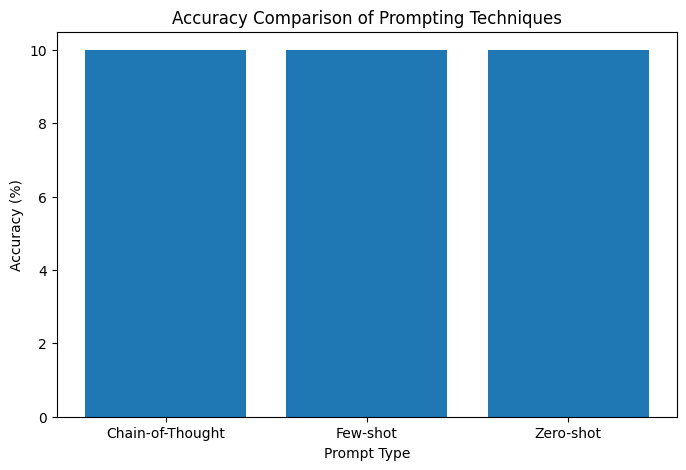

In [30]:
plt.figure(figsize=(8, 5))
plt.bar(accuracy_table["Prompt Type"], accuracy_table["Accuracy (%)"])
plt.xlabel("Prompt Type")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Comparison of Prompting Techniques")
plt.show()